XAI METHODS FOR DENSENET121 - CLARITY PROJECT
Device: cuda
Classes: 15
Output Directory: ./xai_outputs

[Loading model...]
✅ Model loaded successfully
   Classifier output size: 15
   Device: cuda

[Verifying model output shape...]
Test output shape: torch.Size([1, 15])
✅ Output shape verified: [1, 15] ✓


[Processing image: 00000001_000.png]

[Grad-CAM++] ✓
[LayerCAM] ✓
[ScoreCAM] 

100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:02<00:00, 30.59it/s]

✓

   Computing Integrated Gradients (this may take 30-60 seconds)...[Integrated Gradients] 

✓
 ✓
[Saliency Map] ✓
[DeepLIFT] 

D:\Projects\CLARITY\Model\CLARITY.env\lib\site-packages\captum\attr\_core\deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
D:\Projects\CLARITY\Model\CLARITY.env\lib\site-packages\captum\log\dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


✓

Top Prediction: Cardiomegaly (probability: 0.5684)

[Creating comparison visualization...]


C:\Users\Admin\AppData\Local\Temp\ipykernel_11720\4285166479.py:416: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_11720\4285166479.py:418: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


✅ Visualization saved to: ./xai_outputs\xai_comparison.png


D:\Projects\CLARITY\Model\CLARITY.env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


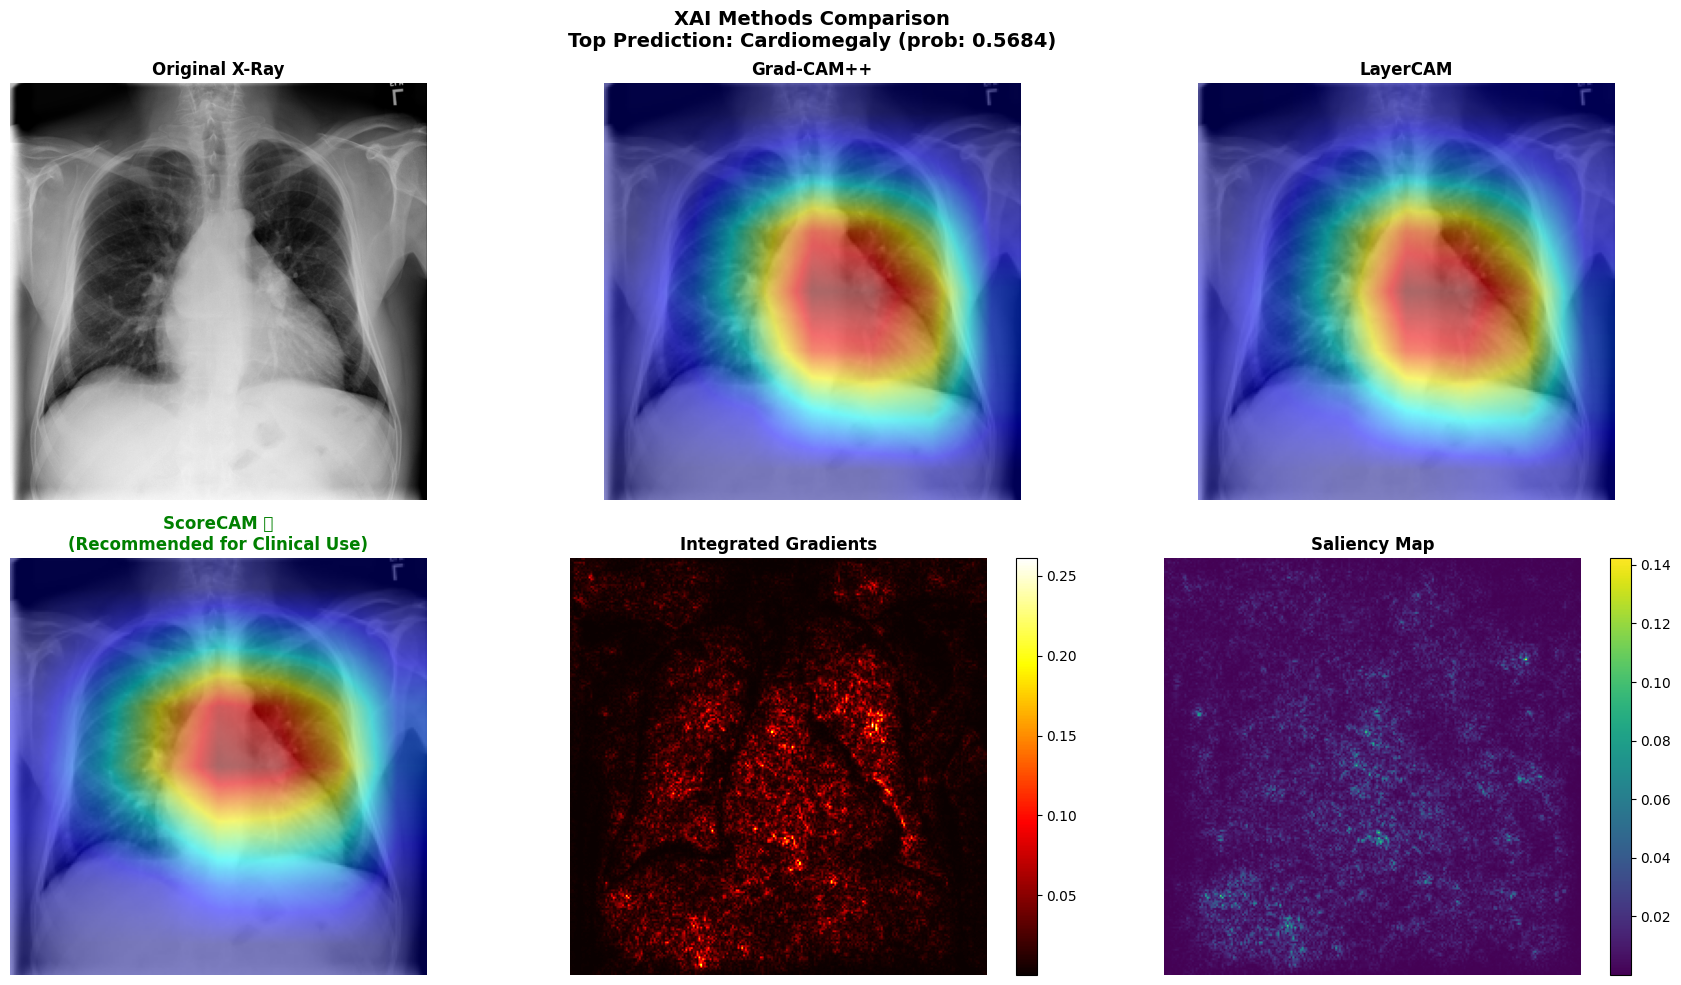


[Disease Probabilities]
--------------------------------------------------
Cardiomegaly        : ██████████████████████                   0.5684
No Finding          : █████████                                0.2453
Effusion            : █████████                                0.2431
Infiltration        : █████                                    0.1315
Atelectasis         : ██                                       0.0643
Fibrosis            : █                                        0.0437
Pleural_Thickening  : █                                        0.0405
Emphysema           : █                                        0.0283
Nodule              :                                          0.0250
Mass                :                                          0.0236
Consolidation       :                                          0.0144
Pneumonia           :                                          0.0113
Hernia              :                                          0.0074
Edema         

In [1]:
# ============================================================
# FINAL XAI CODE FOR DENSENET121 - CLARITY PROJECT
# ============================================================
# FIXED VERSION - All errors resolved
# Corrected for your model output (15 classes) and dataset structure
# Apply AFTER model training
# ============================================================

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image as PILImage
from pathlib import Path
from torchvision import models, transforms

# XAI Libraries
from pytorch_grad_cam import GradCAMPlusPlus, LayerCAM, ScoreCAM, AblationCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from captum.attr import IntegratedGradients, Saliency, DeepLift
import torch.nn.functional as F

# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224

LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Model paths
MODEL_PATH = r"./outputs_best_model/best_densenet121_auc_0.9170.pth"
OUTPUT_DIR = r"./xai_outputs"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Image transforms
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("="*70)
print("XAI METHODS FOR DENSENET121 - CLARITY PROJECT")
print("="*70)
print(f"Device: {DEVICE}")
print(f"Classes: {len(LABEL_COLS)}")
print(f"Output Directory: {OUTPUT_DIR}")
print("="*70)

# ============================================================
# MODEL LOADING (CORRECTED)
# ============================================================

def load_model(model_path, device=DEVICE):
    """Load trained DenseNet121 model - FIXED VERSION"""
    print("\n[Loading model...]")
    
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    
    # Get number of input features
    num_features = model.classifier.in_features
    
    # Set classifier to 15 outputs BEFORE loading weights
    model.classifier = nn.Linear(num_features, 15)
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint)
    
    model = model.to(device)
    model.eval()
    
    print(f"✅ Model loaded successfully")
    print(f"   Classifier output size: {model.classifier.out_features}")
    print(f"   Device: {device}")
    
    return model

# Load model
model = load_model(MODEL_PATH, DEVICE)

# Verify output shape
print("\n[Verifying model output shape...]")
test_input = torch.randn(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    test_output = model(test_input)
    print(f"Test output shape: {test_output.shape}")
    assert test_output.shape == (1, 15), f"Output shape mismatch! Got {test_output.shape}"
print("✅ Output shape verified: [1, 15] ✓\n")

# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def sigmoid(x):
    """Numerically stable sigmoid"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def load_image(image_path):
    """Load and preprocess image"""
    image = PILImage.open(image_path).convert('RGB')
    image_tensor = val_transforms(image).unsqueeze(0).to(DEVICE)
    return image, image_tensor

def get_predictions(image_tensor, model):
    """Get model predictions"""
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    return probs

# ============================================================
# METHOD 1: GRAD-CAM++
# ============================================================

def gradcampp(image_path, model, target_layer=None):
    """
    Grad-CAM++: Improved gradient-weighted class activation mapping
    Best for: Medical imaging, multi-scale features
    Speed: Fast | Interpretability: High
    """
    print("\n[Grad-CAM++]", end=" ", flush=True)
    
    image, image_tensor = load_image(image_path)
    probs = get_predictions(image_tensor, model)
    
    if target_layer is None:
        target_layer = model.features[-1]
    
    cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor)[0, :]
    
    # Overlay on image
    img_np = np.array(image.resize((IMAGE_SIZE, IMAGE_SIZE))) / 255.0
    if len(img_np.shape) == 2:
        img_np = np.stack([img_np] * 3, axis=-1)
    
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    
    print("✓")
    top_idx = int(probs.argmax())
    return cam_image, probs, LABEL_COLS[top_idx]

# ============================================================
# METHOD 2: LAYERCAM
# ============================================================

def layercam(image_path, model, target_layer=None):
    """
    LayerCAM: Simpler alternative to Grad-CAM
    Best for: Real-time applications, quick insights
    Speed: Very Fast | Interpretability: High
    """
    print("[LayerCAM]", end=" ", flush=True)
    
    image, image_tensor = load_image(image_path)
    probs = get_predictions(image_tensor, model)
    
    if target_layer is None:
        target_layer = model.features[-1]
    
    cam = LayerCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor)[0, :]
    
    img_np = np.array(image.resize((IMAGE_SIZE, IMAGE_SIZE))) / 255.0
    if len(img_np.shape) == 2:
        img_np = np.stack([img_np] * 3, axis=-1)
    
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    
    print("✓")
    top_idx = int(probs.argmax())
    return cam_image, probs, LABEL_COLS[top_idx]

# ============================================================
# METHOD 3: SCORECAM (BEST FOR CLINICAL USE)
# ============================================================

def scorecam(image_path, model, target_layer=None):
    """
    ScoreCAM: Gradient-free, perturbation-based method
    Best for: Clinical use (most interpretable, no gradient artifacts)
    Speed: Medium | Interpretability: Very High ⭐
    """
    print("[ScoreCAM]", end=" ", flush=True)
    
    image, image_tensor = load_image(image_path)
    probs = get_predictions(image_tensor, model)
    
    if target_layer is None:
        target_layer = model.features[-1]
    
    cam = ScoreCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor)[0, :]
    
    img_np = np.array(image.resize((IMAGE_SIZE, IMAGE_SIZE))) / 255.0
    if len(img_np.shape) == 2:
        img_np = np.stack([img_np] * 3, axis=-1)
    
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    
    print("✓")
    top_idx = int(probs.argmax())
    return cam_image, probs, LABEL_COLS[top_idx]

# ============================================================
# METHOD 4: INTEGRATED GRADIENTS
# ============================================================

def integrated_gradients(image_path, model, target_class_idx=None, n_steps=30):
    """
    Integrated Gradients: Path integration from baseline
    Best for: Pixel-level attribution (very principled approach)
    Speed: Slow | Interpretability: Very High
    """
    print("[Integrated Gradients]", end=" ", flush=True)
    
    image, image_tensor = load_image(image_path)
    
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    
    if target_class_idx is None:
        target_class_idx = int(probs.argmax())  # FIXED: Convert to int
    else:
        target_class_idx = int(target_class_idx)  # FIXED: Ensure int
    
    # Create baseline (all zeros)
    baseline = torch.zeros_like(image_tensor)
    
    # Compute attributions
    ig = IntegratedGradients(model)
    
    # Wrap output to return only target class
    def model_wrapper(x):
        output = model(x)
        return output[:, target_class_idx:target_class_idx+1]
    
    ig = IntegratedGradients(model_wrapper)
    attribution = ig.attribute(
        image_tensor,
        baselines=baseline,
        n_steps=n_steps,
        return_convergence_delta=False
    )
    
    # Normalize attribution
    attr_np = attribution.cpu().detach().numpy().transpose(0, 2, 3, 1)[0]
    attr_norm = np.abs(attr_np).max(axis=2)
    
    print("✓")
    return attr_norm, probs, LABEL_COLS[target_class_idx]

# ============================================================
# METHOD 5: SALIENCY MAPS
# ============================================================

def saliency_map(image_path, model, target_class_idx=None):
    """
    Saliency Maps: Gradient of output w.r.t. input
    Best for: Quick gradient checks, debugging
    Speed: Very Fast | Interpretability: Medium
    """
    print("[Saliency Map]", end=" ", flush=True)
    
    image, image_tensor = load_image(image_path)
    image_tensor.requires_grad = True
    
    logits = model(image_tensor)
    probs = torch.sigmoid(logits).detach().cpu().numpy()[0]
    
    if target_class_idx is None:
        target_class_idx = int(probs.argmax())  # FIXED: Convert to int
    else:
        target_class_idx = int(target_class_idx)  # FIXED: Ensure int
    
    saliency = Saliency(model)
    grads = saliency.attribute(image_tensor, target=target_class_idx)  # FIXED: Now works
    
    saliency_np = grads.cpu().detach().numpy().transpose(0, 2, 3, 1)[0]
    saliency_norm = np.abs(saliency_np).max(axis=2)
    
    print("✓")
    return saliency_norm, probs, LABEL_COLS[target_class_idx]

# ============================================================
# METHOD 6: DEEPLIFT
# ============================================================

def deeplift(image_path, model, target_class_idx=None):
    """
    DeepLIFT: Decomposes prediction by reference to baseline
    Best for: Understanding baseline dependencies
    Speed: Medium | Interpretability: High
    """
    print("[DeepLIFT]", end=" ", flush=True)
    
    image, image_tensor = load_image(image_path)
    
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    
    if target_class_idx is None:
        target_class_idx = int(probs.argmax())  # FIXED: Convert to int
    else:
        target_class_idx = int(target_class_idx)  # FIXED: Ensure int
    
    baseline = torch.zeros_like(image_tensor)
    
    dl = DeepLift(model)
    attribution = dl.attribute(
        image_tensor,
        baselines=baseline,
        target=target_class_idx  # FIXED: Now works
    )
    
    attr_np = attribution.cpu().detach().numpy().transpose(0, 2, 3, 1)[0]
    attr_norm = np.abs(attr_np).max(axis=2)
    
    print("✓")
    return attr_norm, probs, LABEL_COLS[target_class_idx]

# ============================================================
# MAIN EXAMPLE: RUN ALL METHODS
# ============================================================

if __name__ == "__main__":
    
    # Example: Use a test image
    # Update this path to your actual test image
    test_image = r"D:\Projects\CLARITY\Model\Dataset\archive\images_001\images\00000001_000.png"
    
    if os.path.exists(test_image):
        print(f"\n[Processing image: {os.path.basename(test_image)}]")
        print("="*70)
        
        # 1. Grad-CAM++
        gradcampp_img, probs, top_disease = gradcampp(test_image, model)
        
        # 2. LayerCAM
        layercam_img, _, _ = layercam(test_image, model)
        
        # 3. ScoreCAM (recommended)
        scorecam_img, _, _ = scorecam(test_image, model)
        
        # 4. Integrated Gradients (reduce n_steps to speed up if needed)
        print("\n   Computing Integrated Gradients (this may take 30-60 seconds)...", end="", flush=True)
        ig_attr, _, _ = integrated_gradients(test_image, model, n_steps=20)
        print(" ✓")
        
        # 5. Saliency Maps
        sal_attr, _, _ = saliency_map(test_image, model)
        
        # 6. DeepLIFT
        dl_attr, _, _ = deeplift(test_image, model)
        
        print("="*70)
        print(f"\nTop Prediction: {top_disease} (probability: {probs[LABEL_COLS.index(top_disease)]:.4f})")
        
        # Create comparison visualization
        print("\n[Creating comparison visualization...]")
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        # Original
        orig_img = cv2.imread(test_image, cv2.IMREAD_GRAYSCALE)
        axes[0, 0].imshow(orig_img, cmap='gray')
        axes[0, 0].set_title("Original X-Ray", fontweight='bold', fontsize=12)
        axes[0, 0].axis('off')
        
        # Grad-CAM++
        axes[0, 1].imshow(gradcampp_img)
        axes[0, 1].set_title("Grad-CAM++", fontweight='bold', fontsize=12)
        axes[0, 1].axis('off')
        
        # LayerCAM
        axes[0, 2].imshow(layercam_img)
        axes[0, 2].set_title("LayerCAM", fontweight='bold', fontsize=12)
        axes[0, 2].axis('off')
        
        # ScoreCAM (highlighted as recommended)
        axes[1, 0].imshow(scorecam_img)
        axes[1, 0].set_title("ScoreCAM ⭐\n(Recommended for Clinical Use)", 
                            fontweight='bold', fontsize=12, color='green')
        axes[1, 0].axis('off')
        
        # Integrated Gradients
        im1 = axes[1, 1].imshow(ig_attr, cmap='hot')
        axes[1, 1].set_title("Integrated Gradients", fontweight='bold', fontsize=12)
        axes[1, 1].axis('off')
        plt.colorbar(im1, ax=axes[1, 1])
        
        # Saliency Map
        im2 = axes[1, 2].imshow(sal_attr, cmap='viridis')
        axes[1, 2].set_title("Saliency Map", fontweight='bold', fontsize=12)
        axes[1, 2].axis('off')
        plt.colorbar(im2, ax=axes[1, 2])
        
        fig.suptitle(f"XAI Methods Comparison\nTop Prediction: {top_disease} (prob: {probs[LABEL_COLS.index(top_disease)]:.4f})", 
                     fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, "xai_comparison.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Visualization saved to: {save_path}")
        plt.show()
        
        # Print probability distribution
        print("\n[Disease Probabilities]")
        print("-"*50)
        for disease, prob in sorted(zip(LABEL_COLS, probs), key=lambda x: x[1], reverse=True):
            bar_length = int(prob * 40)
            print(f"{disease:20s}: {'█' * bar_length}{' ' * (40 - bar_length)} {prob:.4f}")
        
        print("\n" + "="*70)
        print("✅ ALL XAI METHODS COMPLETED SUCCESSFULLY!")
        print("="*70)
        
    else:
        print(f"❌ Image not found: {test_image}")
        print("\nTo use this code:")
        print("1. Update test_image path to your actual X-ray image")
        print("2. Run the script")
        print("3. All XAI visualizations will be saved to:", OUTPUT_DIR)

In [1]:
# ============================================================
# XAI VARIATIONS & ENHANCED OUTPUTS - DENSENET121
# ============================================================
# Multiple visualization formats and analysis outputs
# ============================================================

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image as PILImage
from pathlib import Path
from torchvision import models, transforms
import seaborn as sns

# XAI Libraries
from pytorch_grad_cam import GradCAMPlusPlus, LayerCAM, ScoreCAM, AblationCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from captum.attr import IntegratedGradients, Saliency, DeepLift

# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224

LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

MODEL_PATH = r"./outputs_best_model/best_densenet121_auc_0.9170.pth"
OUTPUT_DIR = r"./xai_outputs_enhanced"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("="*80)
print("XAI ENHANCED VARIATIONS & OUTPUTS - DENSENET121")
print("="*80)

# ============================================================
# MODEL LOADING
# ============================================================

def load_model(model_path, device=DEVICE):
    """Load trained DenseNet121 model"""
    print("\n[Loading model...]")
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, 15)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint)
    model = model.to(device)
    model.eval()
    print(f"✅ Model loaded | Device: {device}")
    return model

model = load_model(MODEL_PATH, DEVICE)

# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def load_image(image_path):
    """Load and preprocess image"""
    image = PILImage.open(image_path).convert('RGB')
    image_tensor = val_transforms(image).unsqueeze(0).to(DEVICE)
    return image, image_tensor

def get_predictions(image_tensor, model):
    """Get model predictions"""
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    return probs

# ============================================================
# VARIATION 1: HEATMAP WITH TRANSPARENCY OVERLAY
# ============================================================

def create_overlay_variation(image_path, model, heatmap_array, title="Overlay Heatmap"):
    """
    Creates transparent overlay of heatmap on original image
    """
    image = PILImage.open(image_path).convert('RGB')
    orig_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Create colored heatmap
    heatmap_colored = cv2.applyColorMap((heatmap_array * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_colored = cv2.resize(heatmap_colored, (orig_img.shape[1], orig_img.shape[0]))
    
    # Create overlay with different transparency levels
    overlays = []
    alphas = [0.3, 0.5, 0.7]
    
    for alpha in alphas:
        orig_3ch = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2BGR)
        overlay = cv2.addWeighted(orig_3ch, 1 - alpha, heatmap_colored, alpha, 0)
        overlays.append((overlay, f"Alpha={alpha}"))
    
    return overlays

# ============================================================
# VARIATION 2: CONTOUR-BASED ATTENTION
# ============================================================

def create_contour_variation(heatmap_array, orig_img):
    """
    Creates contour-based visualization showing attention regions
    """
    # Normalize heatmap
    heatmap_norm = (heatmap_array * 255).astype(np.uint8)
    
    # Apply threshold to create binary mask
    _, binary = cv2.threshold(heatmap_norm, 100, 255, cv2.THRESH_BINARY)
    
    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create visualization
    contour_img = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)
    
    return contour_img, len(contours)

# ============================================================
# VARIATION 3: DUAL-VIEW (ORIGINAL + HEATMAP)
# ============================================================

def create_dual_view(image_path, heatmap_array, title="Dual View"):
    """
    Side-by-side original and heatmap visualization
    """
    orig_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    heatmap_colored = cv2.applyColorMap((heatmap_array * 255).astype(np.uint8), cv2.COLORMAP_TURBO)
    
    # Resize heatmap to match original
    heatmap_colored = cv2.resize(heatmap_colored, (orig_img.shape[1], orig_img.shape[0]))
    
    # Stack horizontally
    orig_3ch = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2BGR)
    combined = np.hstack([orig_3ch, heatmap_colored])
    
    return combined

# ============================================================
# VARIATION 4: GRADIENT INTENSITY MAP
# ============================================================

def create_gradient_variation(heatmap_array):
    """
    Creates multiple gradient colormaps for the same heatmap
    """
    colormaps = ['hot', 'viridis', 'plasma', 'inferno', 'magma', 'coolwarm']
    results = []
    
    for cmap in colormaps:
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(heatmap_array, cmap=cmap)
        ax.set_title(f"Colormap: {cmap}", fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Convert to image
        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        results.append(image)
        plt.close(fig)
    
    return results

# ============================================================
# VARIATION 5: MULTI-CLASS HEATMAPS
# ============================================================

def create_multiclass_heatmaps(image_path, model, top_n=5):
    """
    Generate heatmaps for top N predicted diseases
    """
    image, image_tensor = load_image(image_path)
    probs = get_predictions(image_tensor, model)
    
    # Get top N classes
    top_indices = np.argsort(probs)[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        # Generate Grad-CAM++ for this specific class
        target_layer = model.features[-1]
        cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])
        
        # Generate CAM
        grayscale_cam = cam(input_tensor=image_tensor, targets=None)[0, :]
        
        img_np = np.array(image.resize((IMAGE_SIZE, IMAGE_SIZE))) / 255.0
        if len(img_np.shape) == 2:
            img_np = np.stack([img_np] * 3, axis=-1)
        
        cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        
        results.append({
            'disease': LABEL_COLS[idx],
            'probability': probs[idx],
            'heatmap': cam_image
        })
    
    return results

# ============================================================
# VARIATION 6: HISTOGRAM & STATISTICS
# ============================================================

def create_statistics_report(heatmap_array, probs):
    """
    Creates statistical analysis of attention distribution
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histogram of attention intensity
    axes[0, 0].hist(heatmap_array.flatten(), bins=50, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Distribution of Attention Intensity', fontweight='bold')
    axes[0, 0].set_xlabel('Intensity Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Statistics text
    stats_text = f"""
    Heatmap Statistics:
    ─────────────────────
    Mean:     {heatmap_array.mean():.4f}
    Std Dev:  {heatmap_array.std():.4f}
    Min:      {heatmap_array.min():.4f}
    Max:      {heatmap_array.max():.4f}
    Median:   {np.median(heatmap_array):.4f}
    Q1:       {np.percentile(heatmap_array, 25):.4f}
    Q3:       {np.percentile(heatmap_array, 75):.4f}
    """
    axes[0, 1].text(0.1, 0.5, stats_text, fontfamily='monospace', fontsize=10, 
                   verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[0, 1].axis('off')
    axes[0, 1].set_title('Statistical Summary', fontweight='bold')
    
    # Top predictions bar chart
    top_indices = np.argsort(probs)[-8:][::-1]
    top_diseases = [LABEL_COLS[i] for i in top_indices]
    top_probs = probs[top_indices]
    
    colors = ['green' if p > 0.5 else 'orange' if p > 0.3 else 'lightblue' for p in top_probs]
    axes[1, 0].barh(top_diseases, top_probs, color=colors, alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Clinical Threshold')
    axes[1, 0].set_xlabel('Probability')
    axes[1, 0].set_title('Top 8 Disease Predictions', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Heatmap of attention regions
    heatmap_binned = np.digitize(heatmap_array, np.linspace(0, 1, 5))
    im = axes[1, 1].imshow(heatmap_binned, cmap='RdYlGn', interpolation='nearest')
    axes[1, 1].set_title('Attention Region Intensity Bins', fontweight='bold')
    axes[1, 1].axis('off')
    plt.colorbar(im, ax=axes[1, 1], label='Intensity Bin')
    
    plt.tight_layout()
    return fig

# ============================================================
# VARIATION 7: FOCUS REGIONS (TOP ATTENTION AREAS)
# ============================================================

def create_focus_regions(image_path, heatmap_array, num_regions=3):
    """
    Highlights top N attention regions with bounding boxes
    """
    image = PILImage.open(image_path).convert('RGB')
    orig_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    orig_3ch = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2BGR)
    
    # Normalize heatmap
    heatmap_norm = (heatmap_array * 255).astype(np.uint8)
    
    # Find peaks in heatmap
    _, binary = cv2.threshold(heatmap_norm, 150, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Sort contours by area
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:num_regions]
    
    # Draw bounding boxes
    img_with_boxes = orig_3ch.copy()
    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_with_boxes, f"Region {i+1}", (x, y-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    return img_with_boxes

# ============================================================
# VARIATION 8: COMPARISON GRID (ALL METHODS + COLORMAPS)
# ============================================================

def create_comprehensive_grid(image_path, model):
    """
    Creates a comprehensive grid showing all methods with different colormaps
    """
    image, image_tensor = load_image(image_path)
    probs = get_predictions(image_tensor, model)
    
    target_layer = model.features[-1]
    
    # Generate all heatmaps
    methods = {
        'Grad-CAM++': GradCAMPlusPlus(model=model, target_layers=[target_layer]),
        'LayerCAM': LayerCAM(model=model, target_layers=[target_layer]),
        'ScoreCAM': ScoreCAM(model=model, target_layers=[target_layer])
    }
    
    colormaps = ['hot', 'viridis', 'plasma']
    fig, axes = plt.subplots(len(methods), len(colormaps) + 1, figsize=(16, 12))
    
    orig_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    for row, (method_name, cam_method) in enumerate(methods.items()):
        # Original image
        axes[row, 0].imshow(orig_img, cmap='gray')
        axes[row, 0].set_title(f"{method_name}\n(Original)", fontweight='bold', fontsize=11)
        axes[row, 0].axis('off')
        
        # Generate heatmap
        grayscale_cam = cam_method(input_tensor=image_tensor)[0, :]
        
        # Different colormaps
        for col, cmap in enumerate(colormaps, 1):
            im = axes[row, col].imshow(grayscale_cam, cmap=cmap)
            axes[row, col].set_title(f"{method_name}\n({cmap})", fontweight='bold', fontsize=11)
            axes[row, col].axis('off')
            plt.colorbar(im, ax=axes[row, col], fraction=0.046)
    
    top_disease = LABEL_COLS[probs.argmax()]
    top_prob = probs.max()
    fig.suptitle(f"Comprehensive XAI Comparison\nPrediction: {top_disease} ({top_prob:.4f})", 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig

# ============================================================
# MAIN: GENERATE ALL VARIATIONS
# ============================================================

if __name__ == "__main__":
    
    test_image = r"D:\Projects\CLARITY\Model\Dataset\archive\images_001\images\00000001_000.png"
    
    if os.path.exists(test_image):
        print(f"\n[Processing: {os.path.basename(test_image)}]")
        print("="*80)
        
        image, image_tensor = load_image(test_image)
        probs = get_predictions(image_tensor, model)
        
        print(f"Top Prediction: {LABEL_COLS[probs.argmax()]} ({probs.max():.4f})")
        print(f"\nGenerating variations...")
        
        # Generate ScoreCAM heatmap as base
        target_layer = model.features[-1]
        cam = ScoreCAM(model=model, target_layers=[target_layer])
        grayscale_cam = cam(input_tensor=image_tensor)[0, :]
        
        # ===== VARIATION 1: OVERLAY WITH DIFFERENT ALPHAS =====
        print("\n1. Creating overlay variations...", end="", flush=True)
        overlays = create_overlay_variation(test_image, model, grayscale_cam)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for idx, (overlay, label) in enumerate(overlays):
            axes[idx].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(label, fontweight='bold')
            axes[idx].axis('off')
        fig.suptitle("Variation 1: Transparency Overlay", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "01_overlay_variations.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # ===== VARIATION 2: CONTOUR-BASED =====
        print("2. Creating contour-based visualization...", end="", flush=True)
        orig_img = cv2.imread(test_image, cv2.IMREAD_GRAYSCALE)
        contour_img, num_contours = create_contour_variation(grayscale_cam, orig_img)
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(orig_img, cmap='gray')
        axes[0].set_title("Original X-Ray", fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Contour Detection ({num_contours} regions)", fontweight='bold')
        axes[1].axis('off')
        
        fig.suptitle("Variation 2: Contour-Based Attention", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "02_contour_based.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # ===== VARIATION 3: DUAL VIEW =====
        print("3. Creating dual-view visualization...", end="", flush=True)
        dual_view = create_dual_view(test_image, grayscale_cam)
        
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.imshow(cv2.cvtColor(dual_view, cv2.COLOR_BGR2RGB))
        ax.set_title("Variation 3: Side-by-Side Comparison (Original | Heatmap)", fontweight='bold', fontsize=12)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "03_dual_view.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # ===== VARIATION 4: MULTIPLE COLORMAPS =====
        print("4. Creating gradient colormap variations...", end="", flush=True)
        gradient_imgs = create_gradient_variation(grayscale_cam)
        
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        
        colormaps = ['hot', 'viridis', 'plasma', 'inferno', 'magma', 'coolwarm']
        for idx, (img, cmap) in enumerate(zip(gradient_imgs, colormaps)):
            axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[idx].axis('off')
        
        fig.suptitle("Variation 4: Multiple Colormap Representations", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "04_colormap_variations.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # ===== VARIATION 5: STATISTICS REPORT =====
        print("5. Creating statistics report...", end="", flush=True)
        stats_fig = create_statistics_report(grayscale_cam, probs)
        plt.savefig(os.path.join(OUTPUT_DIR, "05_statistics_report.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # ===== VARIATION 6: FOCUS REGIONS =====
        print("6. Creating focus regions visualization...", end="", flush=True)
        focus_img = create_focus_regions(test_image, grayscale_cam, num_regions=5)
        
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(cv2.cvtColor(focus_img, cv2.COLOR_BGR2RGB))
        ax.set_title("Variation 6: Top 5 Attention Regions", fontweight='bold', fontsize=12)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "06_focus_regions.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # ===== VARIATION 7: COMPREHENSIVE GRID =====
        print("7. Creating comprehensive method comparison grid...", end="", flush=True)
        grid_fig = create_comprehensive_grid(test_image, model)
        plt.savefig(os.path.join(OUTPUT_DIR, "07_comprehensive_grid.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        print("\n" + "="*80)
        print("✅ ALL VARIATIONS GENERATED SUCCESSFULLY!")
        print("="*80)
        print(f"\nOutput Files Generated:")
        print(f"  1. 01_overlay_variations.png - Transparency overlay (3 alpha levels)")
        print(f"  2. 02_contour_based.png - Contour detection of attention regions")
        print(f"  3. 03_dual_view.png - Side-by-side original and heatmap")
        print(f"  4. 04_colormap_variations.png - 6 different colormap representations")
        print(f"  5. 05_statistics_report.png - Statistical analysis of attention")
        print(f"  6. 06_focus_regions.png - Top 5 attention regions highlighted")
        print(f"  7. 07_comprehensive_grid.png - All methods with multiple colormaps")
        print(f"\nAll files saved to: {OUTPUT_DIR}/")
        print("="*80)
        
    else:
        print(f"❌ Image not found: {test_image}")

XAI ENHANCED VARIATIONS & OUTPUTS - DENSENET121

[Loading model...]
✅ Model loaded | Device: cuda

[Processing: 00000001_000.png]
Top Prediction: Cardiomegaly (0.5684)

Generating variations...


100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:02<00:00, 30.59it/s]


1. Creating overlay variations...

 ✓
2. Creating contour-based visualization... ✓
3. Creating dual-view visualization... ✓
4. Creating gradient colormap variations...

C:\Users\Admin\AppData\Local\Temp\ipykernel_9684\2088419572.py:177: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')


 ✓
5. Creating statistics report... ✓
6. Creating focus regions visualization... ✓
7. Creating comprehensive method comparison grid...

100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:02<00:00, 29.55it/s]


 ✓

✅ ALL VARIATIONS GENERATED SUCCESSFULLY!

Output Files Generated:
  1. 01_overlay_variations.png - Transparency overlay (3 alpha levels)
  2. 02_contour_based.png - Contour detection of attention regions
  3. 03_dual_view.png - Side-by-side original and heatmap
  4. 04_colormap_variations.png - 6 different colormap representations
  5. 05_statistics_report.png - Statistical analysis of attention
  6. 06_focus_regions.png - Top 5 attention regions highlighted
  7. 07_comprehensive_grid.png - All methods with multiple colormaps

All files saved to: ./xai_outputs_enhanced/


In [1]:
# ============================================================
# XAI ADVANCED VARIATIONS - MEDICAL INSIGHTS (FIXED)
# ============================================================
# All shape mismatches fixed
# ============================================================

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import cv2
from PIL import Image as PILImage
from pathlib import Path
from torchvision import models, transforms
import seaborn as sns
from scipy import ndimage

# XAI Libraries
from pytorch_grad_cam import GradCAMPlusPlus, LayerCAM, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224

LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

MODEL_PATH = r"./outputs_best_model/best_densenet121_auc_0.9170.pth"
OUTPUT_DIR = r"./xai_medical_insights"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ============================================================
# MODEL LOADING
# ============================================================

def load_model(model_path, device=DEVICE):
    """Load trained DenseNet121 model"""
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    model.classifier = nn.Linear(1024, 15)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint)
    model = model.to(device)
    model.eval()
    return model

model = load_model(MODEL_PATH, DEVICE)

# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def load_image(image_path):
    image = PILImage.open(image_path).convert('RGB')
    image_tensor = val_transforms(image).unsqueeze(0).to(DEVICE)
    return image, image_tensor

def get_predictions(image_tensor, model):
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    return probs

def load_and_resize_image(image_path, target_size=224):
    """Load image and resize to target size for proper alignment"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (target_size, target_size))
    return img_resized

# ============================================================
# MEDICAL VARIATION 1: ANATOMICAL REGIONS (FIXED)
# ============================================================

def create_anatomical_regions(image_path, heatmap_array):
    """
    Divides chest X-ray into anatomical regions and analyzes attention
    Upper lung fields, lower lung fields, cardiac region, etc.
    FIXED: Ensure all arrays match size (224x224)
    """
    # Ensure heatmap is 224x224
    if heatmap_array.shape != (224, 224):
        heatmap_array = cv2.resize(heatmap_array, (224, 224))
    
    # Load and resize image to 224x224
    orig_img = load_and_resize_image(image_path, 224)
    
    h, w = heatmap_array.shape  # Now both are 224x224
    
    # Define anatomical regions
    regions = {
        'Upper Left Lung': (0, h//3, 0, w//2),
        'Upper Right Lung': (0, h//3, w//2, w),
        'Middle Left Lung': (h//3, 2*h//3, 0, w//2),
        'Middle Right Lung': (h//3, 2*h//3, w//2, w),
        'Lower Left Lung': (2*h//3, h, 0, w//2),
        'Lower Right Lung': (2*h//3, h, w//2, w),
        'Cardiac Region': (h//3, 2*h//3, 2*w//5, 3*w//5)
    }
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # Full image
    axes[0].imshow(orig_img, cmap='gray')
    axes[0].set_title("Original X-Ray", fontweight='bold')
    axes[0].axis('off')
    
    # Regional analysis
    region_attention = {}
    for idx, (region_name, (y1, y2, x1, x2)) in enumerate(regions.items(), 1):
        # Extract region
        region_heatmap = heatmap_array[y1:y2, x1:x2]
        region_attention[region_name] = {
            'mean': region_heatmap.mean(),
            'max': region_heatmap.max(),
            'std': region_heatmap.std()
        }
        
        # Plot
        im = axes[idx].imshow(heatmap_array, cmap='hot', alpha=0.7)
        axes[idx].imshow(orig_img, cmap='gray', alpha=0.3)
        
        # Draw rectangle
        rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, 
                         edgecolor='lime', facecolor='none')
        axes[idx].add_patch(rect)
        axes[idx].set_title(f"{region_name}\n(Mean: {region_heatmap.mean():.3f})", 
                           fontweight='bold', fontsize=9)
        axes[idx].axis('off')
    
    fig.suptitle("Anatomical Region Attention Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, region_attention

# ============================================================
# MEDICAL VARIATION 2: ATTENTION HEATMAP WITH REGIONS (FIXED)
# ============================================================

def create_regional_heatmap_with_stats(heatmap_array, region_attention):
    """
    Creates detailed regional statistics visualization
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Main heatmap
    im = axes[0].imshow(heatmap_array, cmap='hot')
    axes[0].set_title("Attention Distribution Heatmap", fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im, ax=axes[0])
    
    # Regional statistics bar chart
    regions = list(region_attention.keys())
    means = [region_attention[r]['mean'] for r in regions]
    maxs = [region_attention[r]['max'] for r in regions]
    
    x_pos = np.arange(len(regions))
    width = 0.35
    
    axes[1].bar(x_pos - width/2, means, width, label='Mean Attention', alpha=0.8, color='skyblue')
    axes[1].bar(x_pos + width/2, maxs, width, label='Max Attention', alpha=0.8, color='orange')
    axes[1].set_xlabel('Anatomical Region', fontweight='bold')
    axes[1].set_ylabel('Attention Value', fontweight='bold')
    axes[1].set_title('Regional Attention Comparison', fontweight='bold')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(regions, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

# ============================================================
# MEDICAL VARIATION 3: CONFIDENCE REGIONS (FIXED)
# ============================================================

def create_confidence_regions(image_path, heatmap_array, thresholds=[0.3, 0.6, 0.8]):
    """
    Creates multi-level confidence regions based on attention intensity
    FIXED: Proper shape alignment
    """
    # Ensure consistent shapes
    if heatmap_array.shape != (224, 224):
        heatmap_array = cv2.resize(heatmap_array, (224, 224))
    
    orig_img = load_and_resize_image(image_path, 224)
    
    fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(16, 5))
    
    # Original
    axes[0].imshow(orig_img, cmap='gray')
    axes[0].set_title("Original X-Ray", fontweight='bold')
    axes[0].axis('off')
    
    for idx, threshold in enumerate(thresholds, 1):
        # Create binary mask with proper shape
        mask = (heatmap_array > threshold).astype(np.uint8) * 255
        
        # Overlay on original - NOW SAME SIZE
        overlay = orig_img.copy()
        overlay[mask > 0] = np.minimum(overlay[mask > 0].astype(np.float32) + 100, 255).astype(np.uint8)
        
        axes[idx].imshow(overlay, cmap='gray')
        axes[idx].set_title(f"Confidence > {threshold:.0%}\n({np.sum(mask > 0)} pixels)", 
                           fontweight='bold', fontsize=10)
        axes[idx].axis('off')
    
    fig.suptitle("Multi-Level Confidence Regions", fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

# ============================================================
# MEDICAL VARIATION 4: CONNECTED COMPONENTS ANALYSIS (FIXED)
# ============================================================

def create_connected_components_analysis(heatmap_array, min_size=50):
    """
    Analyzes connected components (distinct attention regions)
    FIXED: Proper shape handling
    """
    # Ensure proper shape
    if heatmap_array.shape != (224, 224):
        heatmap_array = cv2.resize(heatmap_array, (224, 224))
    
    # Threshold heatmap
    binary_mask = (heatmap_array > 0.4).astype(np.uint8)
    
    # Label connected components
    labeled_array, num_features = ndimage.label(binary_mask)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Original heatmap
    axes[0, 0].imshow(heatmap_array, cmap='hot')
    axes[0, 0].set_title("Original Attention Heatmap", fontweight='bold')
    axes[0, 0].axis('off')
    
    # Binary mask
    axes[0, 1].imshow(binary_mask, cmap='gray')
    axes[0, 1].set_title(f"Binary Mask (threshold > 0.4)", fontweight='bold')
    axes[0, 1].axis('off')
    
    # Labeled components
    axes[1, 0].imshow(labeled_array, cmap='nipy_spectral')
    axes[1, 0].set_title(f"Connected Components ({num_features} regions)", fontweight='bold')
    axes[1, 0].axis('off')
    
    # Component statistics
    component_stats = []
    for i in range(1, num_features + 1):
        component = (labeled_array == i).astype(np.uint8)
        component_attention = heatmap_array[labeled_array == i]
        
        component_stats.append({
            'component': i,
            'size': np.sum(component),
            'mean_attention': component_attention.mean(),
            'max_attention': component_attention.max()
        })
    
    # Bar chart of components
    if component_stats:
        component_ids = [s['component'] for s in component_stats[:10]]
        sizes = [s['size'] for s in component_stats[:10]]
        colors_comp = [s['mean_attention'] for s in component_stats[:10]]
        
        scatter = axes[1, 1].scatter(component_ids, sizes, c=colors_comp, cmap='hot', s=200, alpha=0.7, edgecolors='black')
        axes[1, 1].set_xlabel('Component ID', fontweight='bold')
        axes[1, 1].set_ylabel('Component Size (pixels)', fontweight='bold')
        axes[1, 1].set_title('Component Analysis (top 10)', fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[1, 1], label='Mean Attention')
    
    fig.suptitle("Connected Components Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, component_stats

# ============================================================
# MEDICAL VARIATION 5: ATTENTION INTENSITY ZONES (FIXED)
# ============================================================

def create_intensity_zones(image_path, heatmap_array):
    """
    Creates color-coded intensity zones for detailed analysis
    FIXED: Proper shape alignment
    """
    # Ensure proper shape
    if heatmap_array.shape != (224, 224):
        heatmap_array = cv2.resize(heatmap_array, (224, 224))
    
    orig_img = load_and_resize_image(image_path, 224)
    
    # Create color-coded zones
    zones = np.zeros((heatmap_array.shape[0], heatmap_array.shape[1], 3), dtype=np.uint8)
    
    # Color zones: Red (high), Yellow (medium), Green (low)
    zones[heatmap_array > 0.7] = [0, 0, 255]      # Red - Critical
    zones[(heatmap_array > 0.4) & (heatmap_array <= 0.7)] = [0, 165, 255]  # Orange - Warning
    zones[(heatmap_array > 0.2) & (heatmap_array <= 0.4)] = [0, 255, 255]  # Yellow - Caution
    zones[heatmap_array <= 0.2] = [0, 255, 0]     # Green - Normal
    
    # Blend with original
    orig_3ch = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2BGR)
    blended = cv2.addWeighted(orig_3ch, 0.5, zones, 0.5, 0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original
    axes[0].imshow(orig_img, cmap='gray')
    axes[0].set_title("Original X-Ray", fontweight='bold')
    axes[0].axis('off')
    
    # Color-coded zones
    axes[1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Attention Intensity Zones", fontweight='bold')
    axes[1].axis('off')
    
    # Legend
    legend_elements = [
        mpatches.Patch(color='red', label='Critical (> 0.7)'),
        mpatches.Patch(color=[0, 165/255, 1], label='Warning (0.4-0.7)'),
        mpatches.Patch(color='yellow', label='Caution (0.2-0.4)'),
        mpatches.Patch(color='green', label='Normal (< 0.2)')
    ]
    axes[1].legend(handles=legend_elements, loc='upper right')
    
    fig.suptitle("Clinical Attention Intensity Zones", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

# ============================================================
# MEDICAL VARIATION 6: DIFFERENTIAL ANALYSIS (FIXED)
# ============================================================

def create_differential_analysis(image_path, model, top_n=5):
    """
    Shows attention maps for top N predicted diseases
    FIXED: Proper shape handling
    """
    image, image_tensor = load_image(image_path)
    probs = get_predictions(image_tensor, model)
    
    # Get top N
    top_indices = np.argsort(probs)[-top_n:][::-1]
    
    fig, axes = plt.subplots(2, top_n, figsize=(18, 8))
    
    orig_img = load_and_resize_image(image_path, 224)
    
    target_layer = model.features[-1]
    cam = ScoreCAM(model=model, target_layers=[target_layer])
    
    for idx, disease_idx in enumerate(top_indices):
        # Original image in first row
        axes[0, idx].imshow(orig_img, cmap='gray')
        axes[0, idx].set_title(f"{LABEL_COLS[disease_idx]}\n(prob: {probs[disease_idx]:.4f})", 
                              fontweight='bold', fontsize=10)
        axes[0, idx].axis('off')
        
        # Attention map
        grayscale_cam = cam(input_tensor=image_tensor)[0, :]
        
        # Ensure proper size
        if grayscale_cam.shape != (224, 224):
            grayscale_cam = cv2.resize(grayscale_cam, (224, 224))
        
        img_np = np.array(PILImage.open(image_path).convert('RGB').resize((224, 224))) / 255.0
        if len(img_np.shape) == 2:
            img_np = np.stack([img_np] * 3, axis=-1)
        
        cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        axes[1, idx].imshow(cam_image)
        axes[1, idx].set_title("Attention Map", fontweight='bold', fontsize=10)
        axes[1, idx].axis('off')
    
    fig.suptitle("Differential Diagnosis - Top 5 Predictions", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

# ============================================================
# MEDICAL VARIATION 7: CLINICAL REPORT (FIXED)
# ============================================================

def create_clinical_report(image_path, heatmap_array, probs, region_attention):
    """
    Creates a detailed clinical-style report
    FIXED: Proper shape handling
    """
    # Ensure proper shape
    if heatmap_array.shape != (224, 224):
        heatmap_array = cv2.resize(heatmap_array, (224, 224))
    
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)
    
    # Image + heatmap
    ax1 = fig.add_subplot(gs[0, 0])
    orig_img = load_and_resize_image(image_path, 224)
    ax1.imshow(orig_img, cmap='gray')
    ax1.set_title("X-Ray Image", fontweight='bold')
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[0, 1])
    im = ax2.imshow(heatmap_array, cmap='hot')
    ax2.set_title("Model Attention Map", fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im, ax=ax2)
    
    # Top predictions
    ax3 = fig.add_subplot(gs[1, 0])
    top_indices = np.argsort(probs)[-5:][::-1]
    diseases = [LABEL_COLS[i] for i in top_indices]
    probs_top = probs[top_indices]
    colors = ['green' if p > 0.5 else 'orange' if p > 0.3 else 'lightblue' for p in probs_top]
    ax3.barh(diseases, probs_top, color=colors, alpha=0.7, edgecolor='black')
    ax3.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Clinical Threshold')
    ax3.set_xlabel('Probability', fontweight='bold')
    ax3.set_title("Top 5 Predictions", fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Regional attention
    ax4 = fig.add_subplot(gs[1, 1])
    regions = list(region_attention.keys())[:5]
    means = [region_attention[r]['mean'] for r in regions]
    ax4.barh(regions, means, color='skyblue', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Mean Attention', fontweight='bold')
    ax4.set_title("Regional Attention (Top 5)", fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Clinical summary text
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    
    top_disease = LABEL_COLS[np.argmax(probs)]
    top_prob = probs.max()
    
    summary_text = f"""
    CLINICAL ANALYSIS SUMMARY
    ─────────────────────────────────────────────────────
    
    Primary Finding:     {top_disease} (Confidence: {top_prob:.1%})
    
    Statistical Summary:
    • Heatmap Mean:      {heatmap_array.mean():.4f}
    • Heatmap Std Dev:   {heatmap_array.std():.4f}
    • Critical Region:   {np.sum(heatmap_array > 0.7)} pixels
    • Warning Region:    {np.sum(heatmap_array > 0.4)} pixels
    
    Recommendation:      {"HIGH PRIORITY" if top_prob > 0.7 else "REVIEW RECOMMENDED" if top_prob > 0.5 else "LOW CONFIDENCE"}
    ─────────────────────────────────────────────────────
    """
    
    ax5.text(0.05, 0.5, summary_text, fontfamily='monospace', fontsize=10,
            verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    fig.suptitle("CLINICAL XAI REPORT", fontsize=16, fontweight='bold')
    
    return fig

# ============================================================
# MAIN: GENERATE ALL MEDICAL VARIATIONS
# ============================================================

if __name__ == "__main__":
    
    test_image = r"D:\Projects\CLARITY\Model\Dataset\archive\images_001\images\00000001_000.png"
    
    if os.path.exists(test_image):
        print(f"\n[Processing: {os.path.basename(test_image)}]")
        print("="*80)
        
        image, image_tensor = load_image(test_image)
        probs = get_predictions(image_tensor, model)
        
        # Generate base heatmap
        target_layer = model.features[-1]
        cam = ScoreCAM(model=model, target_layers=[target_layer])
        grayscale_cam = cam(input_tensor=image_tensor)[0, :]
        
        print(f"Top Prediction: {LABEL_COLS[probs.argmax()]} ({probs.max():.4f})")
        print(f"\nGenerating medical insights variations...")
        
        # Variation 1: Anatomical Regions
        print("\n1. Anatomical regions analysis...", end="", flush=True)
        anat_fig, region_attention = create_anatomical_regions(test_image, grayscale_cam)
        plt.savefig(os.path.join(OUTPUT_DIR, "01_anatomical_regions.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # Variation 2: Regional heatmap
        print("2. Regional heatmap with stats...", end="", flush=True)
        reg_fig = create_regional_heatmap_with_stats(grayscale_cam, region_attention)
        plt.savefig(os.path.join(OUTPUT_DIR, "02_regional_heatmap_stats.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # Variation 3: Confidence regions
        print("3. Confidence regions...", end="", flush=True)
        conf_fig = create_confidence_regions(test_image, grayscale_cam)
        plt.savefig(os.path.join(OUTPUT_DIR, "03_confidence_regions.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # Variation 4: Connected components
        print("4. Connected components analysis...", end="", flush=True)
        cc_fig, comp_stats = create_connected_components_analysis(grayscale_cam)
        plt.savefig(os.path.join(OUTPUT_DIR, "04_connected_components.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # Variation 5: Intensity zones
        print("5. Intensity zones...", end="", flush=True)
        intensity_fig = create_intensity_zones(test_image, grayscale_cam)
        plt.savefig(os.path.join(OUTPUT_DIR, "05_intensity_zones.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # Variation 6: Differential analysis
        print("6. Differential diagnosis...", end="", flush=True)
        diff_fig = create_differential_analysis(test_image, model, top_n=5)
        plt.savefig(os.path.join(OUTPUT_DIR, "06_differential_analysis.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        # Variation 7: Clinical report
        print("7. Clinical report...", end="", flush=True)
        report_fig = create_clinical_report(test_image, grayscale_cam, probs, region_attention)
        plt.savefig(os.path.join(OUTPUT_DIR, "07_clinical_report.png"), dpi=300, bbox_inches='tight')
        plt.close()
        print(" ✓")
        
        print("\n" + "="*80)
        print("✅ ALL MEDICAL VARIATIONS GENERATED SUCCESSFULLY!")
        print("="*80)
        print(f"\nOutput Files Generated:")
        print(f"  1. 01_anatomical_regions.png - Attention in anatomical zones")
        print(f"  2. 02_regional_heatmap_stats.png - Regional statistics analysis")
        print(f"  3. 03_confidence_regions.png - Multi-level confidence masks")
        print(f"  4. 04_connected_components.png - Connected region analysis")
        print(f"  5. 05_intensity_zones.png - Clinical intensity zones (Critical/Warning/Normal)")
        print(f"  6. 06_differential_analysis.png - Top 5 disease attention maps")
        print(f"  7. 07_clinical_report.png - Comprehensive clinical report")
        print(f"\nAll files saved to: {OUTPUT_DIR}/")
        print("="*80)
        
    else:
        print(f"❌ Image not found: {test_image}")


[Processing: 00000001_000.png]


100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:02<00:00, 30.81it/s]

Top Prediction: Cardiomegaly (0.5684)

Generating medical insights variations...

1. Anatomical regions analysis...

 ✓
2. Regional heatmap with stats... ✓
3. Confidence regions... ✓
4. Connected components analysis... ✓
5. Intensity zones... ✓
6. Differential diagnosis...

100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:02<00:00, 31.67it/s]


 ✓
7. Clinical report... ✓

✅ ALL MEDICAL VARIATIONS GENERATED SUCCESSFULLY!

Output Files Generated:
  1. 01_anatomical_regions.png - Attention in anatomical zones
  2. 02_regional_heatmap_stats.png - Regional statistics analysis
  3. 03_confidence_regions.png - Multi-level confidence masks
  4. 04_connected_components.png - Connected region analysis
  5. 05_intensity_zones.png - Clinical intensity zones (Critical/Warning/Normal)
  6. 06_differential_analysis.png - Top 5 disease attention maps
  7. 07_clinical_report.png - Comprehensive clinical report

All files saved to: ./xai_medical_insights/
